<a href="https://colab.research.google.com/github/binsue0/.github/blob/main/DL_day5/11_1_time_series_prediction_with_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="한국어 해설 수정본을 Colab에서 열기"/></a>

# 11-1. Transformer로 시계열의 다음 값 예측하기

과거 **4개월의 항공 승객 수로 다음 1개월의 승객 수**를 예측합니다. PyTorch로 만든 작은 모델을 읽으면서 데이터 전처리, 입력 형태 변환, Multi-Head Self-Attention, Encoder, 학습과 평가를 연결하는 실습입니다.

이 모델은 **직접 구현한 Encoder 기반 회귀 모델**입니다. 강의자료의 완전한 Encoder-Decoder 번역 모델이나 사전학습된 LLM을 사용하는 것이 아닙니다.

### 학습 목표

1. 시계열을 입력 윈도우와 정답으로 나누고 각 배열의 크기를 설명한다.
2. 코드의 `W_Q`, `W_K`, `W_V`, `einsum`, `softmax`를 Attention 수식과 연결한다.
3. Encoder의 잔차 연결·정규화·FFN 역할을 이해한다.
4. 1-step 예측과 여러 단계 미래 예측을 구분하고 평가상의 한계를 찾는다.

원본 코드 참고:

- [Univariate Time-Series Prediction 예제 저장소](https://github.com/hee9joon/Univariate-Time-Series-Prediction-using-Deep-Learning)
- [PyTorch 시계열 예측 참고 노트북](https://colab.research.google.com/github/dlmacedo/starter-academic/blob/master/content/courses/deeplearning/notebooks/pytorch/Time_Series_Prediction_with_LSTM_Using_PyTorch.ipynb)

### 강의자료와 연결해서 읽기

기준 자료: **D06 Transformer2026R.pdf**. 아래 쪽수는 표지부터 세는 PDF 뷰어 기준입니다.

| 강의 내용 | PDF 쪽 | 이 실습에서 찾을 위치 |
|---|---|---|
| Q/K/V, Scaled Dot-Product Attention | 51–57 | `AttentionBlock`의 선형변환·내적·softmax |
| Multi-Head Attention | 60–68 | head 분할, `einsum`, 출력 연결 |
| FFN, 잔차 연결, LayerNorm | 74–75, 89 | `EncoderBlock` |
| 위치 정보 | 76–81 | 이 코드에는 명시적 positional encoding이 없음 |
| Decoder masking과 cross-attention | 95–99 | 이 Encoder 회귀 모델에는 해당 Decoder가 없음 |

먼저 데이터의 크기를 따라가고, 모델 셀에서는 수식과 축 표를 함께 보세요. 주의사항은 “이 코드가 실제로 하는 일”과 “개선하면 좋은 일”을 구분해 적었습니다.

## 1. 데이터 내려받기

아래 두 셀은 CSV 파일을 현재 작업 폴더에 내려받습니다. `!`는 Python 문장이 아니라 노트북에서 운영체제 명령을 실행한다는 뜻입니다.

- `airline-passengers.csv`: 본 실습에서 사용하는 월별 항공 승객 수 데이터입니다.
- `shampoo.csv`: 마지막 확장 실습에서 사용할 월별 샴푸 판매량 데이터입니다. 다운로드만으로 학습 데이터가 바뀌지는 않습니다.

처음 실행할 때 인터넷 연결과 `wget`이 필요합니다. 다운로드 실패 시 파일이 있는지 먼저 확인하세요. 셀을 반복 실행하면 `.1` 등의 이름으로 중복 파일이 생길 수 있습니다.

In [ ]:
!wget https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv

--2025-03-31 00:40:41--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519 [text/plain]
Saving to: ‘shampoo.csv’

shampoo.csv         100%[===================>]     519  --.-KB/s    in 0s      

2025-03-31 00:40:42 (17.6 MB/s) - ‘shampoo.csv’ saved [519/519]



In [ ]:
!wget https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv

--2025-03-31 00:40:42--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2180 (2.1K) [text/plain]
Saving to: ‘airline-passengers.csv’

airline-passengers. 100%[===================>]   2.13K  --.-KB/s    in 0s      

2025-03-31 00:40:42 (43.8 MB/s) - ‘airline-passengers.csv’ saved [2180/2180]



## 2. 라이브러리 불러오기

| 라이브러리·도구 | 이 노트북에서 하는 일 |
|---|---|
| `pandas` | CSV를 읽고 예측할 열을 선택 |
| `numpy` | 배열 연결, 윈도우 생성, 그래프의 인덱스 구성 |
| `matplotlib.pyplot` | 실제값·예측값 시각화 |
| `torch`, `torch.nn` | 텐서 연산, 신경망 계층, 손실함수·학습 |
| `torch.nn.functional` | Attention 가중치 계산에 사용하는 `softmax` |
| `StandardScaler` | 학습 구간 통계로 표준화하고 최종 예측을 역변환 |

`Variable`은 과거 PyTorch에서 사용하던 방식입니다. 현재는 일반 `torch.Tensor`가 자동미분 기능을 갖고 있지만, 여기서는 원본 코드를 유지했습니다.

실행 환경에 NumPy, pandas, Matplotlib, PyTorch, scikit-learn이 필요합니다. **이 코드에는 모델·데이터를 GPU로 옮기는 처리가 없으므로 Colab에서 GPU를 선택해도 그대로는 CPU에서 계산합니다.**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from sklearn.preprocessing import StandardScaler

## 3. 원본 시계열 확인하기

`pd.read_csv`로 항공 승객 데이터를 읽고, `iloc[:, 1:2]`로 **두 번째 열만 2차원 형태로** 선택합니다. `.values`는 DataFrame을 NumPy 배열로 바꿉니다.

- 첫 번째 열인 날짜는 모델 입력에 사용하지 않습니다.
- 표준 항공 데이터는 144개 월별 관측값으로 구성되므로 배열은 `(144, 1)`입니다.
- `training_set`이라는 변수명과 달리, 이 시점에는 **학습·테스트를 나누기 전 전체 데이터**가 들어 있습니다.

그래프에서 전체적인 증가 추세와 반복적인 계절 패턴을 관찰하세요. 입력 길이 4개월은 12개월 주기를 온전히 포함하지 못합니다. 모델이 관찰할 수 있는 정보가 입력 길이에 의해 제한된다는 점을 기억하세요.

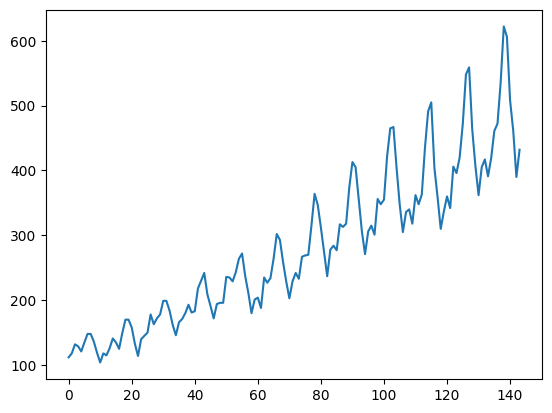

In [ ]:
training_set = pd.read_csv('airline-passengers.csv')
#training_set = pd.read_csv('shampoo.csv')

training_set = training_set.iloc[:,1:2].values

#plt.plot(training_set, label = 'Shampoo Sales Data')
plt.plot(training_set, label = 'Airline Passangers Data')
plt.show()

## 4. 전처리와 학습용 윈도우 만들기

### 4-1. 시간순 분할과 표준화

마지막 20개 관측값을 테스트 구간으로 남겨두고, 앞의 124개 관측값에서 평균과 표준편차를 구합니다.

$$z_t=\frac{x_t-\mu_{\mathrm{train}}}{\sigma_{\mathrm{train}}}.$$

- `fit_transform(training_set[:-test_size])`: 학습 구간에서 통계를 추정하고 변환합니다.
- `transform(training_set[-test_size:])`: **앞에서 구한 통계를 그대로 적용**합니다. 테스트 구간에서 다시 평균·표준편차를 구하지 않습니다.
- `seq_length=4`: 예측에 이용할 과거 관측값 개수입니다.
- `train_size=144-4-20=120`: 원시 학습 데이터 길이 124가 아니라, 나중에 만들어질 **학습 윈도우 개수**입니다.

이 표준화 단계는 테스트 통계를 사용하지 않습니다. 다만 뒤의 학습 코드에서는 테스트 오차를 모델 선택에 사용하므로, 전처리가 적절하다는 사실과 평가 설계가 적절하다는 사실을 구분해야 합니다.

In [ ]:
sc = StandardScaler()
seq_length = 4

test_size = 20
train_size = len(training_set) - seq_length - 20

train_data = sc.fit_transform(training_set[:-test_size])
test_data = sc.transform(training_set[-test_size:])

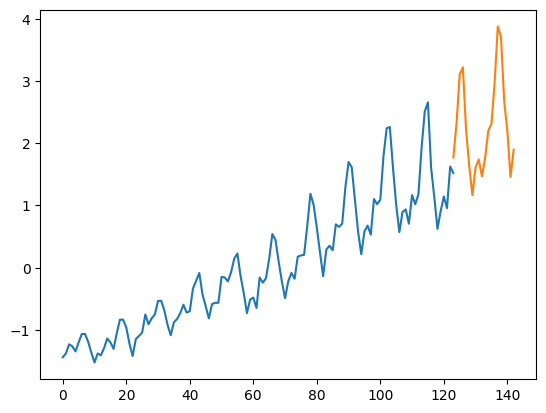

In [ ]:
plt.plot(np.arange(124),train_data)
plt.plot(np.arange(20)+123,test_data)
plt.show()

### 4-2. `sliding_windows`: 과거 4개와 다음 1개를 묶기

입력은 `data[i:i+4]`, 정답은 바로 다음 값 `data[i+4]`입니다. 길이가 `N`인 데이터에서는 `N-4`개의 예제가 생깁니다.

| 예제 | 입력 | 정답 |
|---|---|---|
| 첫 번째 | 관측값 0, 1, 2, 3 | 관측값 4 |
| 두 번째 | 관측값 1, 2, 3, 4 | 관측값 5 |
| 마지막 | 관측값 139, 140, 141, 142 | 관측값 143 |

원시 값 하나를 독립 표본으로 사용하는 것이 아니라, **과거 여러 값을 하나의 입력 표본으로 만드는 과정**입니다. 실제로는 원본값 대신 앞서 표준화한 값이 전달됩니다.

In [ ]:
def sliding_windows(data, seq_length):
    x = []
    y = []
    for i in range(len(data)-seq_length):
        _x = data[i:(i+seq_length)]
        _y = data[i+seq_length]
        x.append(_x)
        y.append(_y)

    return np.array(x),np.array(y)

### 4-3. 윈도우를 만든 뒤 정답 시점으로 학습·테스트 구분하기

`normalized_data`는 동일한 scaler로 변환한 학습·테스트 배열을 다시 연결한 것입니다. 전체에서 윈도우를 만든 뒤 **정답이 마지막 20개 시점에 속하는 윈도우**를 테스트로 분리합니다.

| 변수 | 크기 | 의미 |
|---|---|---|
| `normalized_data` | `(144, 1)` | 표준화한 전체 관측값 |
| `x`, `dataX` | `(140, 4, 1)` | 전체 입력 윈도우 |
| `y`, `dataY` | `(140, 1)` | 전체 정답 |
| `trainX`, `trainY` | `(120, 4, 1)`, `(120, 1)` | 학습 예제 120개 |
| `testX`, `testY` | `(20, 4, 1)`, `(20, 1)` | 테스트 예제 20개 |

마지막 차원 1은 변수 수입니다. 이후 `trainX[:, :, 0]`로 단일 변수 축을 선택하면 `(120, 4)`가 됩니다. `torch.Tensor`는 여기서 수치 데이터를 부동소수점 텐서로 변환합니다.

In [ ]:
normalized_data = np.concatenate([train_data, test_data])
x, y = sliding_windows(normalized_data, seq_length)

dataX = Variable(torch.Tensor(np.array(x)))
dataY = Variable(torch.Tensor(np.array(y)))

trainX = Variable(torch.Tensor(np.array(x[:-test_size])))
trainY = Variable(torch.Tensor(np.array(y[:-test_size])))

testX = Variable(torch.Tensor(np.array(x[-test_size:])))
testY = Variable(torch.Tensor(np.array(y[-test_size:])))

### 여기서의 테스트는 미래 20개월을 한꺼번에 예측하는가?

**아닙니다. 매 시점 실제 과거 4개월을 사용하는 1-step 예측입니다.** 다음 표는 원시 데이터의 0-based 인덱스입니다.

| 예측 | 입력으로 사용하는 실제 관측값 | 정답 시점 |
|---|---|---|
| 첫 테스트 예측 | 120, 121, 122, 123 | 124 |
| 두 번째 테스트 예측 | 121, 122, 123, **124** | 125 |
| 마지막 테스트 예측 | 139, 140, 141, 142 | 143 |

두 번째 예측에는 첫 테스트 시점의 **실제값**이 들어갑니다. 그 시점이 지난 뒤 실제 관측을 얻는 상황을 모사하므로 rolling 1-step 평가에서 허용되는 정보입니다. 반면 마지막 학습 시점에서 실제 미래값을 전혀 받지 않고 20개월을 내다보는 과제와는 다릅니다.

전체 예측을 한 번의 함수 호출로 묶어 계산해도, 각 입력 윈도우에 사용된 정보의 의미는 바뀌지 않습니다. 테스트 20개월 전체의 예측값을 다시 입력으로 넣는 재귀 예측도 아닙니다.

## 5. 모델 구현: Attention → Encoder → 예측 모델

다음 하나의 코드 셀에 세 클래스가 순서대로 정의되어 있습니다.

| 클래스 | 입력 → 출력 | 역할 |
|---|---|---|
| `AttentionBlock` | `(B, 2, 8)` → `(B, 2, 8)` | 두 토큰 사이의 정보를 2개 head로 결합 |
| `EncoderBlock` | `(B, 2, 8)` → `(B, 2, 8)` | Attention, 잔차 연결, LayerNorm, FFN 적용 |
| `Transformer` | `(B, 4)` → `(B, 1)` | 4개 값을 묶어 임베딩하고 Encoder를 거쳐 다음 값 예측 |

여기서 `B`는 윈도우 개수이며, 현재 학습에서는 120입니다. 표의 나머지 크기는 `input_size=4`, `embed_size=16`, `num_layers=3` 설정에 해당합니다.

아래 모델 정의 셀은 **클래스를 정의할 뿐 학습하지 않습니다.** 실제 모델 객체 생성과 가중치 갱신은 다음 학습 절에서 이루어집니다.

### 5-1. 입력 4개가 토큰 2개가 되는 이유

`Transformer.forward`는 입력을 `reshape(-1, 2, input_dim//2)`로 바꿉니다. 현재 설정에서는 과거 4개 값 중 **앞의 2개가 첫 토큰, 뒤의 2개가 두 번째 토큰**입니다. 시점 하나당 토큰 하나가 아닙니다.

| 연산 | 텐서 크기 | 설명 |
|---|---|---|
| 함수 입력 | `(B, 4)` | 각 윈도우의 과거 4개 값 |
| `mean`, `std` | 각각 `(B, 1)` | 윈도우별 평균·표준편차 |
| 정규화 후 `reshape` | `(B, 2, 2)` | 토큰 2개, 토큰당 관측값 2개 |
| `input_layer` | `(B, 2, 8)` | 같은 `Linear(2, 8)`을 각 토큰에 적용 |
| Encoder 3개 | `(B, 2, 8)` | 토큰 수와 토큰별 차원을 유지 |
| `flatten` | `(B, 16)` | 두 토큰을 정해진 순서로 이어 붙임 |
| `output_layer` | `(B, 1)` | 다음 시점의 값 하나를 예측 |
| `x*std+mean` | `(B, 1)` | 윈도우별 정규화를 되돌림 |

토큰을 이렇게 묶는 것은 **이 구현의 설계 선택**입니다. Transformer가 반드시 토큰 2개를 요구하는 것은 아닙니다. `11_2`의 PatchTST와는 “연속 구간을 토큰으로 묶는다”는 발상을 연결할 수 있지만, 이 작은 모델이 PatchTST 자체인 것은 아닙니다.

### 5-2. Q·K·V와 Scaled Dot-Product Attention

강의자료 연결: PDF 뷰어 기준 **51–57쪽**의 Q/K/V·Scaled Dot-Product Attention, **60–68쪽**의 Multi-Head Attention입니다. PDF 페이지와 슬라이드 하단 번호는 다를 수 있습니다.

같은 입력 토큰 행렬 $X$에 서로 다른 학습 가능한 선형변환을 적용합니다. 아래 식은 간결하게 쓰기 위해 bias를 생략했습니다.

$$Q=XW_Q,\qquad K=XW_K,\qquad V=XW_V,$$
$$A=\operatorname{softmax}\left(\frac{QK^\top}{\sqrt{d_h}}\right),\qquad Z=AV.$$

- **Q(Query)**: 현재 토큰이 어떤 정보를 찾을지 나타내는 표현입니다.
- **K(Key)**: 다른 토큰과 얼마나 관련 있는지 비교할 표현입니다.
- **V(Value)**: Attention 가중치로 합칠 실제 정보 표현입니다.
- `self.attn(x, x, x)`이므로 Q/K/V의 **출처는 같지만**, 서로 다른 가중치를 거친 Q/K/V 값까지 같은 것은 아닙니다.
- `self.scale=d_h**-0.5`는 $1/\sqrt{d_h}$입니다. 내적 크기가 커져 softmax가 과도하게 뾰족해지는 현상을 완화합니다.

현재 `d_model=8`, `n_heads=2`이므로 head당 차원은 `d_h=4`입니다. 서로 다른 head가 각기 다른 가중치로 정보를 결합하지만, 특정 head가 반드시 추세나 계절성만 담당한다고 단정할 수는 없습니다.

### 5-3. `einsum`의 축을 읽는 방법

이 코드의 기호는 `b=배치`, `p=query 토큰`, `s=key/value 토큰`, `h=head`, `d=head 내부 차원`입니다. **여기서 `h`는 forecast horizon이 아니라 head 축**입니다.

| 코드 | 계산 | 현재 크기 |
|---|---|---|
| `W_Q(q).view(...)` 등 | head별 표현으로 분리 | `(B, 2, 2, 4)` |
| `'bphd, bshd -> bphs'` | 동일 head에서 Q·K의 `d`축 내적 | `(B, 2, 2, 2)` |
| `softmax(..., dim=-1)` | `s`축, 즉 참조할 토큰들에 걸쳐 정규화 | `(B, 2, 2, 2)` |
| `'bphs, bshd -> bphd'` | `s`축을 합쳐 V의 가중합 계산 | `(B, 2, 2, 4)` |
| `contiguous().view(...)` | head 출력을 연결 | `(B, 2, 8)` |
| `to_out` | 연결된 head 정보를 다시 선형 결합 | `(B, 2, 8)` |

Attention 가중치는 각 `(b, p, h)`에서 마지막 축을 따라 합하면 1입니다. 이 구현은 `(B, head, query, key)`가 아니라 **`(B, query, head, key)` 순서**로 점수를 보관합니다. 모든 축 크기가 2인 예제라 shape만으로는 순서 오류가 드러나지 않으므로 문자열 기호를 함께 보세요.

현재 `AttentionBlock`은 최종 출력만 반환합니다. 뒤의 예측 그래프가 Attention heatmap을 보여주는 것은 아닙니다.

In [ ]:
class AttentionBlock(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        d_h = d_model // n_heads

        self.scale = d_h**-0.5
        self.n_heads, self.d_h = n_heads, d_h

        self.W_Q = nn.Linear(d_model, d_h * n_heads)
        self.W_K = nn.Linear(d_model, d_h * n_heads)
        self.W_V = nn.Linear(d_model, d_h * n_heads)

        self.to_out = nn.Linear(n_heads * d_h, d_model)

    def forward(self, q, k, v):

        bs = q.size(0)
        # Linear (+ split in multiple heads)
        q_s = self.W_Q(q).view(bs, -1, self.n_heads, self.d_h)
        k_s = self.W_K(k).view(bs, -1, self.n_heads, self.d_h)
        v_s = self.W_V(v).view(bs, -1, self.n_heads, self.d_h)

        attn_scores = torch.einsum('bphd, bshd -> bphs', q_s, k_s) * self.scale

        attn_weights = F.softmax(attn_scores, dim=-1)

        output = torch.einsum('bphs, bshd -> bphd', attn_weights, v_s)
        output = output.contiguous().view(bs, -1, self.n_heads*self.d_h)
        output = self.to_out(output)

        return output

class EncoderBlock(nn.Module):
    def __init__(self, input_dim):
        super(EncoderBlock, self).__init__()
        self.input_dim = input_dim

        self.ffn = nn.Sequential(nn.Linear(self.input_dim, 2*self.input_dim),
                        nn.GELU(),
                        nn.Dropout(0.2),
                        nn.Linear(2*self.input_dim, self.input_dim))

        self.layernorm = nn.LayerNorm(self.input_dim)
        self.dropout = nn.Dropout(0.2)
        self.attn = AttentionBlock(self.input_dim, 2)

    def forward(self, x):

        y = self.attn(x,x,x)
        x = x + self.dropout(y)
        x = self.layernorm(x)

        y = self.ffn(x)
        x = x + self.dropout(y)
        y = self.layernorm(x)

        return y

class Transformer(nn.Module):
    def __init__(self, input_dim, emb_dim, out_dim, num_encoder):
        super().__init__()
        self.input_dim = input_dim
        self.emb_dim = emb_dim
        self.input_layer = nn.Linear(input_dim//2, emb_dim//2, bias=True)
        self.encoder_layers = nn.ModuleList([])
        for i in range(num_encoder):
            self.encoder_layers.append(EncoderBlock(emb_dim//2))
            #self.encoder_layers.append(nn.TransformerEncoderLayer(d_model=emb_dim//2, nhead=2,dim_feedforward=emb_dim, dropout=0.2, activation="gelu"))
        self.flatten = nn.Flatten()
        self.output_layer = nn.Linear(emb_dim, out_dim, bias=True)
    def forward(self, x):
        # x: [120,4] 120: batch_size, 4: input_dim
        mean = x.mean(dim=1,keepdim=True)
        std = x.std(dim=1,keepdim=True)
        x = (x-mean)/std
        x = x.reshape(-1, 2, self.input_dim//2) ## Transformer는 Batch를 제외하고 2차원의 Input이 필요하기 때문에 변형.
        # x: [120,2,2]
        x = self.input_layer(x)
        # x: [120,2,8]
        for l in self.encoder_layers:
            x = l(x)
        # x: [120,2,8]
        x = self.flatten(x)
        # x: [120,16]
        x = self.output_layer(x)
        # x: [120,1] 1: out_dim
        x = x*std+mean
        return x

### 5-4. `EncoderBlock`: Attention만으로 끝나지 않는 이유

연산 순서는 **Self-Attention → Dropout·잔차 덧셈 → LayerNorm → FFN → Dropout·잔차 덧셈 → LayerNorm**입니다. 정규화가 각 잔차 덧셈 뒤에 있는 post-norm 구조입니다.

- **잔차 연결** `x + ...`: 입력 정보를 보존하면서 필요한 변화를 학습하게 합니다.
- **LayerNorm(8)**: 각 토큰의 마지막 8개 특징 축을 정규화합니다. 시간축 전체나 배치 전체를 한꺼번에 표준화하는 `StandardScaler`와 다릅니다.
- **FFN** `8 → 16 → 8`: 모든 토큰에 같은 신경망을 개별적으로 적용합니다. `GELU`가 특징별 비선형 변환을 제공합니다. Attention에도 softmax 비선형성이 있으므로 “Attention은 완전히 선형”이라고 설명하면 부정확합니다.
- **Dropout(0.2)**: 학습 시 활성값 일부를 0으로 만들어 과적합을 완화합니다. FFN 안에도 Dropout이 있고, FFN 출력의 잔차 경로에도 Dropout이 적용됩니다.
- **ModuleList**: Encoder들을 정식 하위 모듈로 등록하여 `model.parameters()`와 학습·평가 모드 전환에 포함되게 합니다. Encoder 3개는 서로 다른 가중치를 가집니다.

현재 `EncoderBlock`은 **하나의 `self.layernorm` 객체를 두 번 사용**하여 두 위치의 학습 가능한 scale/bias를 공유합니다. 일반적인 구현처럼 LayerNorm 두 개를 별도로 정의한 것은 아닙니다.

### 5-5. 정규화가 두 번 등장하는 이유

앞의 `StandardScaler`는 **학습 구간 전체**의 통계로 원시 데이터를 변환했습니다. `forward` 안의 `mean`과 `std`는 **각 입력 윈도우의 4개 값**에서 다시 계산합니다.

$$u_{i,j}=\frac{z_{i,j}-m_i}{s_i},\qquad
\hat z_{i}=s_i\,f_\theta(u_i)+m_i.$$

윈도우별 수준·크기 차이를 줄인 상태에서 패턴을 학습하고, 예측 후 그 윈도우의 통계를 되돌리는 발상입니다. `keepdim=True`로 `(B, 1)`을 유지해 `(B, 4)` 전체에 broadcasting할 수 있습니다.

주의할 점:

- `forward` 마지막에서 되돌아온 값도 아직 **StandardScaler가 적용된 척도**입니다. 원래 승객 수 척도로 복원하려면 평가 셀의 `sc.inverse_transform`이 추가로 필요합니다.
- 입력 윈도우 통계만 사용하므로 이 정규화 자체는 정답 미래값을 보지 않습니다.
- 현재 `std`에 0으로 나누는 것을 막는 epsilon이 없습니다. 입력 4개 값이 모두 같으면 `NaN` 등이 생길 수 있어 수정 시 작은 양수 하한을 두는 처리가 필요합니다.
- `torch.std` 기본값은 표본 표준편차 보정(`correction=1`)을 사용합니다. 전체 구간 `StandardScaler`의 표준편차 계산과 구분하세요. [PyTorch `torch.std`](https://docs.pytorch.org/docs/stable/generated/torch.std.html)

이는 윈도우 정규화·역변환을 단순하게 구현한 것이며, 모든 세부 설정까지 정식 RevIN 구현과 같다고 보지는 않습니다.

### 5-6. 강의의 기본 Transformer와 다른 점

**위치 정보:** 이 모델에는 명시적인 positional encoding이 없습니다. 하지만 토큰 안의 두 값이 들어가는 좌표와 마지막 `Flatten + Linear`는 순서를 구분하므로, 전체 모델이 순서에 완전히 무관한 것은 아닙니다. 다만 Encoder의 Attention 자체에는 별도 위치 벡터가 주어지지 않습니다.

**마스킹:** 두 토큰은 모두 예측 시점보다 과거의 관측값입니다. 이 과거 윈도우 안에서 양방향으로 Attention을 적용하는 것 자체는 미래 정답 누수가 아닙니다. 언어 생성 Decoder의 미래 토큰 차단과 구분하세요.

**기본 계층으로 교체할 때:** 주석 처리된 `nn.TransformerEncoderLayer(...)`를 그대로 활성화하면 기본 `batch_first=False`가 현재 `(B, 토큰, 특징)` 배열과 맞지 않습니다. 교체 시 `batch_first=True`를 지정하거나 축을 전치해야 합니다. 그렇지 않으면 배치와 시퀀스가 뒤바뀌어 다른 샘플 사이에서 Attention이 계산될 수 있습니다. [PyTorch EncoderLayer 문서](https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html)

**설정 변경 조건:** 현재 reshape·출력층 구조를 유지한다면 `seq_length=input_size`, `input_size`는 짝수, `embed_size`는 4의 배수로 두는 것이 안전합니다. 두 head로 나누는 차원과 펼친 뒤 출력층 차원이 맞아야 하기 때문입니다. 범용 모델이라면 이런 조건을 assertion으로 검사하도록 개선할 수 있습니다.

## 6. 모델 학습

### 설정과 손실함수

| 설정 | 현재 값 | 해석 |
|---|---:|---|
| `num_epochs` | 5000 | 전체 학습 윈도우를 5000번 사용 |
| `learning_rate` | 0.0001 | Adam의 학습률 |
| `input_size` | 4 | 입력 윈도우 길이; `seq_length`와 같아야 함 |
| `embed_size` | 16 | 두 토큰을 펼친 전체 차원; 토큰별 차원은 8 |
| `num_layers` | 3 | EncoderBlock 반복 횟수 |
| `output_size` | 1 | 다음 시점의 실수 하나를 출력 |

DataLoader나 미니배치 반복문은 없습니다. 한 epoch에 학습 윈도우 120개 전체를 한 번 넣는 **full-batch 학습**이므로 현재 코드에서는 1 epoch에 가중치 업데이트가 1번 일어납니다.

$$\mathrm{MSE}=\frac{1}{B}\sum_{i=1}^{B}(\hat z_i-z_i)^2.$$

모델 출력과 정답은 모두 전체 학습 구간 통계로 표준화된 척도입니다. 따라서 MSE의 수치는 원래 승객 수 단위의 제곱 오차가 아닙니다. 회귀이므로 마지막 출력에 클래스 확률용 softmax를 사용하지 않습니다. Attention 안의 softmax와 예측 출력은 별개입니다.

seed 고정은 반복 실행의 변동을 줄이기 위한 설정입니다. 실행 환경·라이브러리 버전까지 다른 경우 완전히 같은 결과를 보장하지는 않습니다.

### 6-1. 한 번의 학습 반복 읽기

1. `model(trainX[:, :, 0])`: 학습 입력으로 예측값 `(120, 1)`을 계산합니다.
2. `optimizer.zero_grad()`: 이전 반복에 남은 gradient를 지웁니다.
3. `criterion(outputs, trainY)`: 정답과 예측의 MSE를 구합니다.
4. `loss.backward()`: 연결된 모든 학습 파라미터의 gradient를 계산합니다.
5. `optimizer.step()`: Adam이 파라미터를 갱신합니다.

50 epoch마다 `eval()`로 Dropout을 끄고 테스트 입력을 평가한 뒤 `train()`으로 돌아옵니다. **출력되는 `loss`는 학습 MSE가 아니라 그 시점의 테스트 MSE**입니다. `epoch=0` 로그도 첫 업데이트를 마친 뒤의 값입니다. 500 epoch마다만 로그를 출력하므로 모든 검사 결과가 화면에 나오지는 않습니다.

`eval()`은 모델의 동작 모드를 바꾸지만 자동미분을 끄지는 않습니다. 현재 평가 부분에는 `torch.no_grad()`가 없어 불필요한 계산 그래프가 만들어지지만, 테스트 손실로 `backward()`나 `step()`을 호출하지는 않습니다.

### 6-2. 반드시 구분할 것: 테스트 평가와 모델 선택

> **현재 코드는 평가 설계와 best-model 보관에 주의가 필요합니다. 설명만 보강하며 코드는 바꾸지 않았습니다.**

**① 테스트 데이터가 모델 선택에 사용됩니다.** `testY`로 계산한 오차가 최소일 때 모델을 선택합니다. 테스트값으로 gradient를 직접 계산하지 않더라도, 선택에 사용하면 완전히 독립된 테스트 성능이 아닙니다. 학습 구간에서 시간순 validation을 따로 분리하고 validation loss로 선택한 뒤 test는 마지막에 평가하는 방식이 적절합니다.

**② `best_model = model`은 가중치를 복사하지 않습니다.** 같은 모델 객체를 가리키는 이름 하나를 추가합니다. 이후 `optimizer.step()`이 실행되면 `best_model`이 가리키는 가중치도 함께 바뀝니다. 따라서 `best_loss`라는 최소 숫자는 남아도, 그 시점의 모델은 따로 보존되지 않습니다.

수정할 때는 예를 들어 `copy.deepcopy(model.state_dict())`로 **validation 최적 시점의 상태를 복사**하고, 학습 후 해당 상태를 다시 불러와야 합니다. [PyTorch 모델 저장·불러오기 안내](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html)도 이 참조·복사 구분을 설명합니다.

**③ 조기 종료가 구현되어 있지 않습니다.** `best_loss`를 갱신하더라도 반복문을 멈추지 않아 항상 5000 epoch를 수행합니다. 또한 초기 `best_loss=10`보다 작은 유효한 값이 한 번도 없으면 `best_model`은 `None`으로 남아 다음 셀에서 오류가 납니다.

In [ ]:
fix_seed = 42
import random
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

num_epochs = 5000
learning_rate = 0.0001

input_size = 4
embed_size = 16
num_layers = 3

output_size = 1

best_loss = 10
best_model = None

model = Transformer(input_size, embed_size, output_size, num_layers)

criterion = torch.nn.MSELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
#optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Train the model
for epoch in range(num_epochs):
    outputs = model(trainX[:,:,0])
    optimizer.zero_grad()

    # obtain the loss function
    loss = criterion(outputs, trainY)

    loss.backward()

    optimizer.step()
    if epoch % 50 == 0:
      model.eval()
      outputs = model(testX[:,:,0])
      loss = criterion(outputs, testY)
      model.train()
      if loss.item()<best_loss:
        best_loss = loss.item()
        best_model = model
      if epoch % 500 == 0:
        print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

Epoch: 0, loss: 1.12055
Epoch: 500, loss: 0.30763
Epoch: 1000, loss: 0.22441
Epoch: 1500, loss: 0.17292
Epoch: 2000, loss: 0.14695
Epoch: 2500, loss: 0.13473
Epoch: 3000, loss: 0.13134
Epoch: 3500, loss: 0.13411
Epoch: 4000, loss: 0.13997
Epoch: 4500, loss: 0.14219


## 7. 예측값을 원래 단위로 되돌리고 시각화하기

아래 셀은 이름이 `train_predict`이지만 **전체 140개 윈도우**에 대해 예측합니다. 학습 구간과 테스트 구간 예측이 한 그래프에 함께 표시됩니다.

1. `best_model.eval()`: Dropout을 끄고 평가 모드로 바꿉니다.
2. `dataX[:, :, 0]`: 전체 입력을 `(140, 4)`로 바꿉니다.
3. `.data.numpy()`: 현재 CPU 텐서를 NumPy 배열로 꺼냅니다. 새 코드에서는 보통 `torch.no_grad()`와 `detach().cpu().numpy()`를 사용합니다.
4. `sc.inverse_transform`: 표준화된 예측·정답을 원래 데이터의 승객 수 척도로 되돌립니다.
5. 빨간 세로선 `train_size=120`: 예측 배열에서 학습 윈도우와 테스트 윈도우가 갈리는 위치입니다.

그래프의 x축 0은 원시 데이터의 첫 달이 아니라 **5번째 관측값을 예측하는 위치**입니다. x축 120은 원시 데이터의 인덱스 124, 즉 첫 테스트 정답에 해당합니다. `plt.plot` 호출 순서상 첫 선은 실제값, 두 번째 선은 예측값입니다.

> **해석 주의:** 아래 `Best Loss`는 학습 도중 관찰한 최소 테스트 MSE입니다. 앞서 설명한 객체 참조 문제 때문에 현재 `best_model`의 그래프가 그 최소 오차를 기록한 시점의 결과라고 볼 수 없습니다. 또한 테스트 데이터로 모델을 선택했으므로 독립적인 최종 성능으로 보고하면 안 됩니다.

Best Loss: 0.12999282777309418


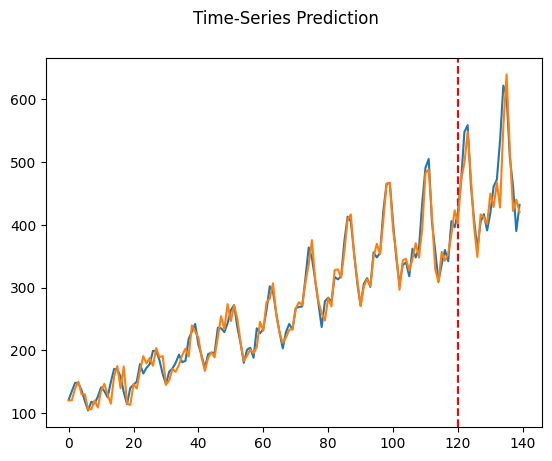

In [ ]:
best_model.eval()
train_predict = best_model(dataX[:,:,0])

data_predict = train_predict.data.numpy()
dataY_plot = dataY.data.numpy()

data_predict = sc.inverse_transform(data_predict)
dataY_plot = sc.inverse_transform(dataY_plot)

plt.axvline(x=train_size, c='r', linestyle='--')

print("Best Loss: {}".format(best_loss))

plt.plot(dataY_plot)
plt.plot(data_predict)
plt.suptitle('Time-Series Prediction')
plt.show()

### 결과를 설명할 때 확인할 질문

1. 학습 구간뿐 아니라 빨간 선 오른쪽의 테스트 구간에서도 추세와 봉우리를 따라가는가?
2. 예측이 실제값보다 늦게 반응하거나 계절적 변화 폭을 작게 잡는가?
3. 직전 실제값을 그대로 다음 값으로 예측하는 단순 기준선보다 나은가? 현재 코드는 이 기준선을 계산하지 않습니다.
4. 그래프가 비슷하게 보이는 것과 독립 테스트의 수치적 성능이 좋다는 것을 구분했는가?

원본 로그에는 뒤쪽 epoch에서 테스트 MSE가 다시 증가하는 구간이 있습니다. 이는 과적합 가능성을 살펴볼 단서지만, 적절한 validation 분리와 모델 복원 없이 최종 성능을 확정할 수는 없습니다.

## 8. 확장 실습: 샴푸 데이터와 설정 변경

원본 과제의 취지는 파라미터와 모델 구조를 바꾸고 샴푸 데이터에 적용해 보는 것입니다. 아래는 **코드를 수정해서 해볼 과제**이며, 현재 셀에 자동으로 적용되어 있지 않습니다.

1. 먼저 시간순 validation을 분리하고, 최적 상태를 복사·복원하는 방식으로 평가 설계를 개선합니다.
2. 항공 데이터에서 입력 길이를 4에서 12로 바꿔 한 해 주기를 볼 수 있게 합니다. `seq_length`와 `input_size`를 함께 바꾸세요. 현재 구조에서는 토큰 수는 여전히 2이고, 토큰당 길이가 6으로 바뀝니다.
3. Encoder 개수·임베딩 차원을 한 번에 하나씩 바꾸고 같은 validation 구간에서 비교합니다.
4. 샴푸 CSV를 선택하고 그래프 길이의 하드코딩도 바꿉니다. 36개 관측값에서 `seq_length=4`, `test_size=20`을 그대로 사용하면 학습 윈도우는 **12개뿐**입니다. 검증 구간까지 분리하려면 작은 데이터 규모에 맞게 실험 범위를 정해야 합니다.
5. 최종적으로 1-step 예측과 실제 미래 관측값을 사용하지 않는 다단계 예측이 어떻게 다른지 설명해 봅니다.

**한 줄 정리:** 과거 4개 관측을 2개 토큰으로 묶고, 토큰 사이의 정보를 Attention으로 결합하여 다음 값 하나를 예측하는 실습입니다.